In [1]:
import pandas as pd
data = pd.read_csv("../data/fd_dataset_messy.csv")
print(data.head(5))

                         email                 time        subject  \
0  mukesh.bhatt@rediffmail.com  2025-02-17 20:29:47  Payment issue   
1      sanjay.jain@hotmail.com  2024-06-07 16:22:21           Help   
2         ashok.nair@gmail.com  2024-04-05 08:16:39     Loan query   
3    manoj.gupta51@hotmail.com  2025-01-04 23:24:05          Query   
4     vinod.chopra87@gmail.com  2025-03-03 10:12:43    Loan status   

                                             content              label  
0  Branch gaya tha, unhone email karne bola. Two ...             Non-FD  
1  Dear customer care, My insurance policy is rea...             Non-FD  
2  Namaskar, Rs 6 lakh kat gaya bina bataye insur...             Non-FD  
3  Dear customer care, 1. Suna hai Bajaj Finance ...  Multiple Category  
4  Dear customer care, Where is my money? The rev...             Non-FD  


In [2]:
# Shape and Types
print("Rows and Columns:",data.shape)

Rows and Columns: (2500, 5)


In [3]:
# Missing Values
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
email      0
time       0
subject    0
content    0
label      0
dtype: int64


In [4]:
# Duplicated Emails
print("Total Emails:",data['subject'].count())
print("Unique Emails:",data['subject'].nunique())
# Because data is generated through AI

Total Emails: 2500
Unique Emails: 44


In [5]:
# Text length
data['content_length'] = data['content'].str.len()
print(data['content_length'].describe())

count    2500.000000
mean      213.234000
std        72.092844
min        80.000000
25%       156.000000
50%       189.000000
75%       273.000000
max       430.000000
Name: content_length, dtype: float64


In [6]:
# Target Variable Distribution
print("Target Variable Distribution:")
print(data['label'].value_counts())

Target Variable Distribution:
label
FD                   1002
Multiple Category     750
Non-FD                748
Name: count, dtype: int64


--- 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette (consistent across all plots) ─────────────────────────────
C_FD       = "#1D9E75"   # teal
C_NONFD    = "#D85A30"   # coral
C_MULTI    = "#7F77DD"   # purple
C_GRAY     = "#888780"
BG         = "#FAFAF8"
FONT       = "DejaVu Sans"

plt.rcParams.update({
    "font.family": FONT,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.facecolor": BG,
    "figure.facecolor": "white",
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

PALETTE = {"FD": C_FD, "Non-FD": C_NONFD, "Multiple Category": C_MULTI}

In [8]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/fd_dataset_messy.csv')
df['time'] = pd.to_datetime(df['time'])
df['word_count'] = df['content'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['content'].apply(lambda x: len(str(x)))
df['month']      = df['time'].dt.month
df['hour']       = df['time'].dt.hour
df['text_combined'] = df['subject'].fillna('') + ' ' + df['content'].fillna('')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total emails     : {len(df):,}")
print(f"Columns          : {df.columns.tolist()}")
print(f"\nClass distribution:")
vc = df['label'].value_counts()
for lbl, cnt in vc.items():
    print(f"  {lbl:<20}: {cnt:>5} ({cnt/len(df)*100:.1f}%)")
print(f"\nNull values      : {df.isnull().sum().sum()} total nulls")
print(f"Date range       : {df['time'].min().date()} → {df['time'].max().date()}")

DATASET OVERVIEW
Total emails     : 2,500
Columns          : ['email', 'time', 'subject', 'content', 'label', 'word_count', 'char_count', 'month', 'hour', 'text_combined']

Class distribution:
  FD                  :  1002 (40.1%)
  Multiple Category   :   750 (30.0%)
  Non-FD              :   748 (29.9%)

Null values      : 0 total nulls
Date range       : 2024-01-01 → 2025-06-24



[✓] plot1_class_distribution.png saved


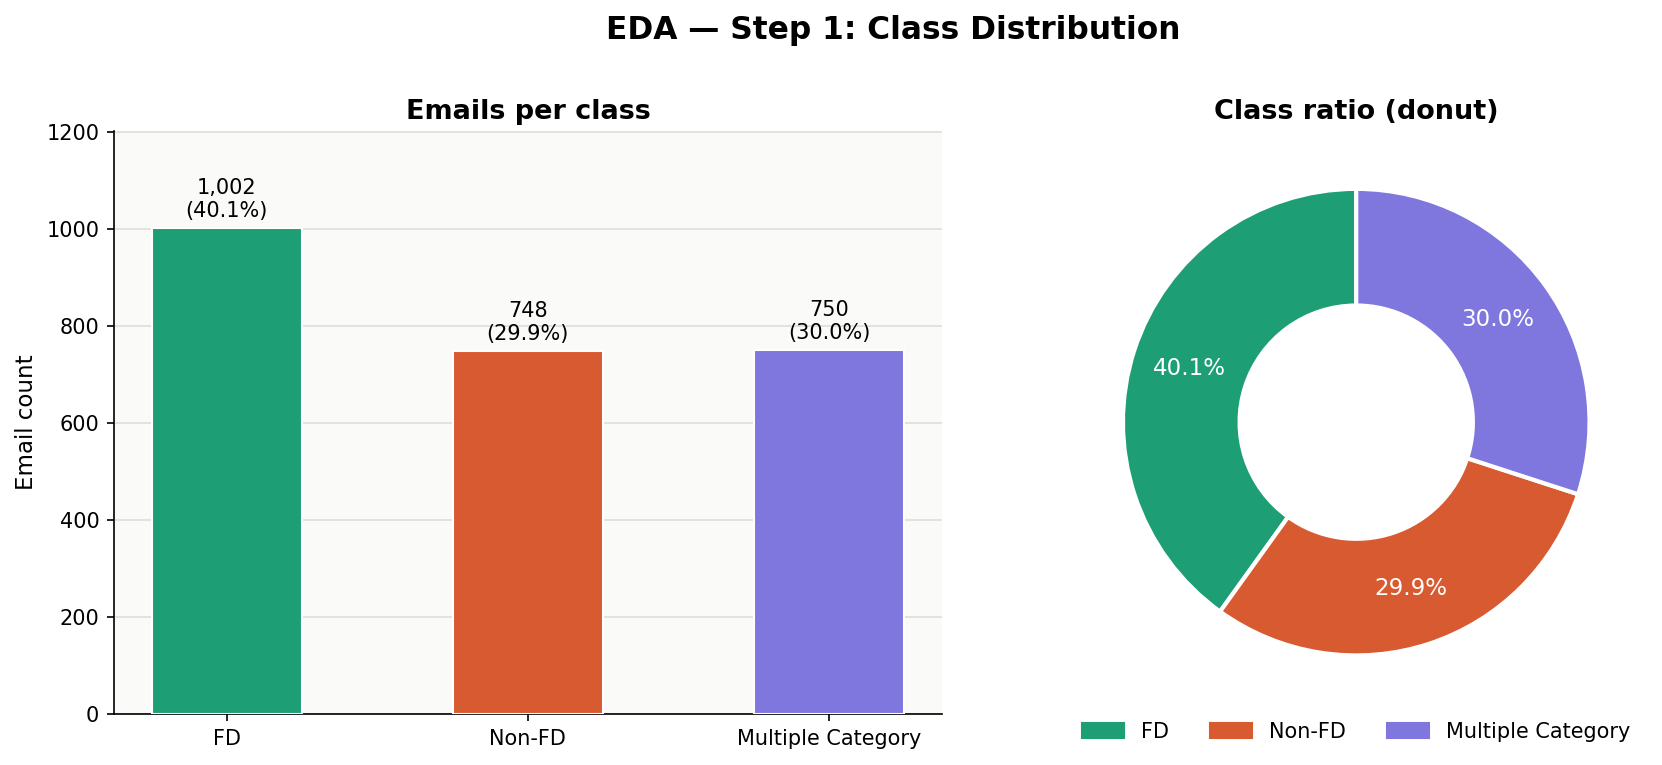

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1  Class Distribution
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("EDA — Step 1: Class Distribution", fontsize=15, fontweight="bold", y=1.01)

labels_order = ["FD", "Non-FD", "Multiple Category"]
counts       = [vc.get(l, 0) for l in labels_order]
colors       = [PALETTE[l] for l in labels_order]

# Bar chart
bars = axes[0].bar(labels_order, counts, color=colors, width=0.5, zorder=3, edgecolor="white")
axes[0].set_facecolor(BG)
axes[0].yaxis.grid(True, color="#E0DED8", zorder=0)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 15,
                 f"{cnt:,}\n({cnt/len(df)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="500")
axes[0].set_ylim(0, max(counts) * 1.2)
axes[0].set_ylabel("Email count")
axes[0].set_title("Emails per class")

# Donut
wedges, texts, autotexts = axes[1].pie(
    counts, labels=None, autopct="%1.1f%%",
    colors=colors, startangle=90,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2),
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight("500"); at.set_color("white")
legend_patches = [mpatches.Patch(color=PALETTE[l], label=l) for l in labels_order]
axes[1].legend(handles=legend_patches, loc="lower center",
               bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=10,
               frameon=False)
axes[1].set_title("Class ratio (donut)")

plt.tight_layout()
plt.savefig("EDA_Image/plot1_class_distribution.png", dpi=150, bbox_inches="tight")
plt.close()
print("\n[✓] plot1_class_distribution.png saved")

from IPython.display import Image, display
image_files = [
    "plot1_class_distribution.png"
]
for img_file in image_files:
    display(Image(filename=f"EDA_Image/{img_file}"))


--- EMAIL LENGTH STATS ---
  FD                  : mean=31.4 words, median=31, max=53
  Non-FD              : mean=30.6 words, median=30, max=51
  Multiple Category   : mean=56.6 words, median=56, max=80
[✓] plot2_email_length.png saved


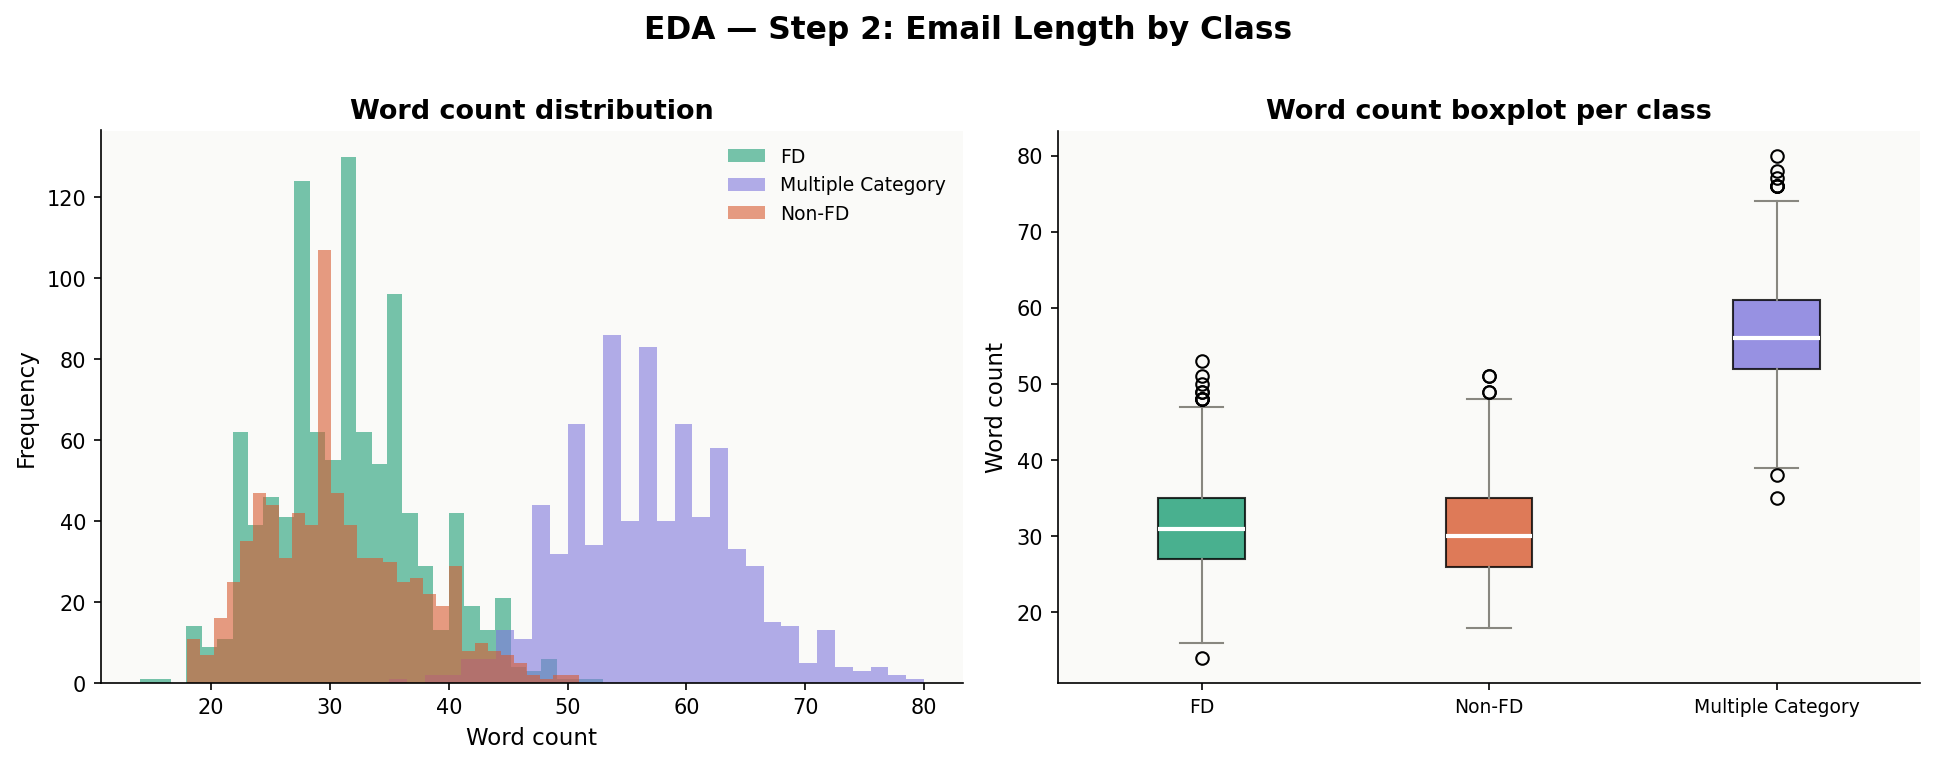

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2  Email Length Analysis
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("EDA — Step 2: Email Length by Class", fontsize=15, fontweight="bold", y=1.01)

for lbl, grp in df.groupby("label"):
    col = PALETTE[lbl]
    axes[0].hist(grp["word_count"], bins=30, alpha=0.6, color=col, label=lbl, edgecolor="none")
axes[0].set_xlabel("Word count"); axes[0].set_ylabel("Frequency")
axes[0].set_title("Word count distribution")
axes[0].legend(fontsize=9, frameon=False)
axes[0].set_facecolor(BG)

# Box plot - word count per class
box_data  = [df[df["label"]==l]["word_count"].values for l in labels_order]
bp = axes[1].boxplot(box_data, patch_artist=True, medianprops=dict(color="white", linewidth=2))
for patch, col in zip(bp["boxes"], colors):
    patch.set_facecolor(col); patch.set_alpha(0.8)
for element in ["whiskers","caps","fliers"]:
    for item in bp[element]:
        item.set(color=C_GRAY, linewidth=1)
axes[1].set_xticks([1,2,3]); axes[1].set_xticklabels(labels_order, fontsize=9)
axes[1].set_ylabel("Word count"); axes[1].set_title("Word count boxplot per class")
axes[1].set_facecolor(BG)

# Print stats
print("\n--- EMAIL LENGTH STATS ---")
for lbl in labels_order:
    g = df[df["label"]==lbl]
    print(f"  {lbl:<20}: mean={g['word_count'].mean():.1f} words, "
          f"median={g['word_count'].median():.0f}, max={g['word_count'].max()}")

plt.tight_layout()
plt.savefig("EDA_Image/plot2_email_length.png", dpi=150, bbox_inches="tight")
plt.close()
print("[✓] plot2_email_length.png saved")

image_files = [
    "plot2_email_length.png"
]
for img_file in image_files:
    display(Image(filename=f"EDA_Image/{img_file}"))

HOW HINGLISH SCORE IS CALCULATED — 3 EXAMPLES

  [Pure English (Non-FD)]
  Text     : I have been trying to resolve an issue for over 3 weeks. I have called customer care 6 tim...
  All words (29)  : ['i', 'have', 'been', 'trying', 'to', 'resolve', 'an', 'issue', 'for', 'over', 'weeks', 'i']...
  Hindi hits (0) : []
  Score    : 0 / 29 = 0.000
  Threshold: 0.03
  Result   : ❌ Not Hinglish

  [Heavy Hinglish (FD)]
  Text     : Namaste mera 2 lakh ka investment aapke yahan hai. Maturity kab hogi aur kitna paisa mileg...
  All words (21)  : ['namaste', 'mera', 'lakh', 'ka', 'investment', 'aapke', 'yahan', 'hai', 'maturity', 'kab', 'hogi', 'aur']...
  Hindi hits (11) : ['mera', 'aapke', 'yahan', 'hai', 'kab', 'aur', 'kitna', 'paisa', 'milega', 'jaldi', 'batao']
  Score    : 11 / 21 = 0.524
  Threshold: 0.03
  Result   : ✅ HINGLISH

  [Light Hinglish (FD)]
  Text     : Mujhe 2022-23 ka TDS certificate chahiye. Income tax filing ke liye. Please email pe bhej ...
  All words (20)  : ['mujhe',

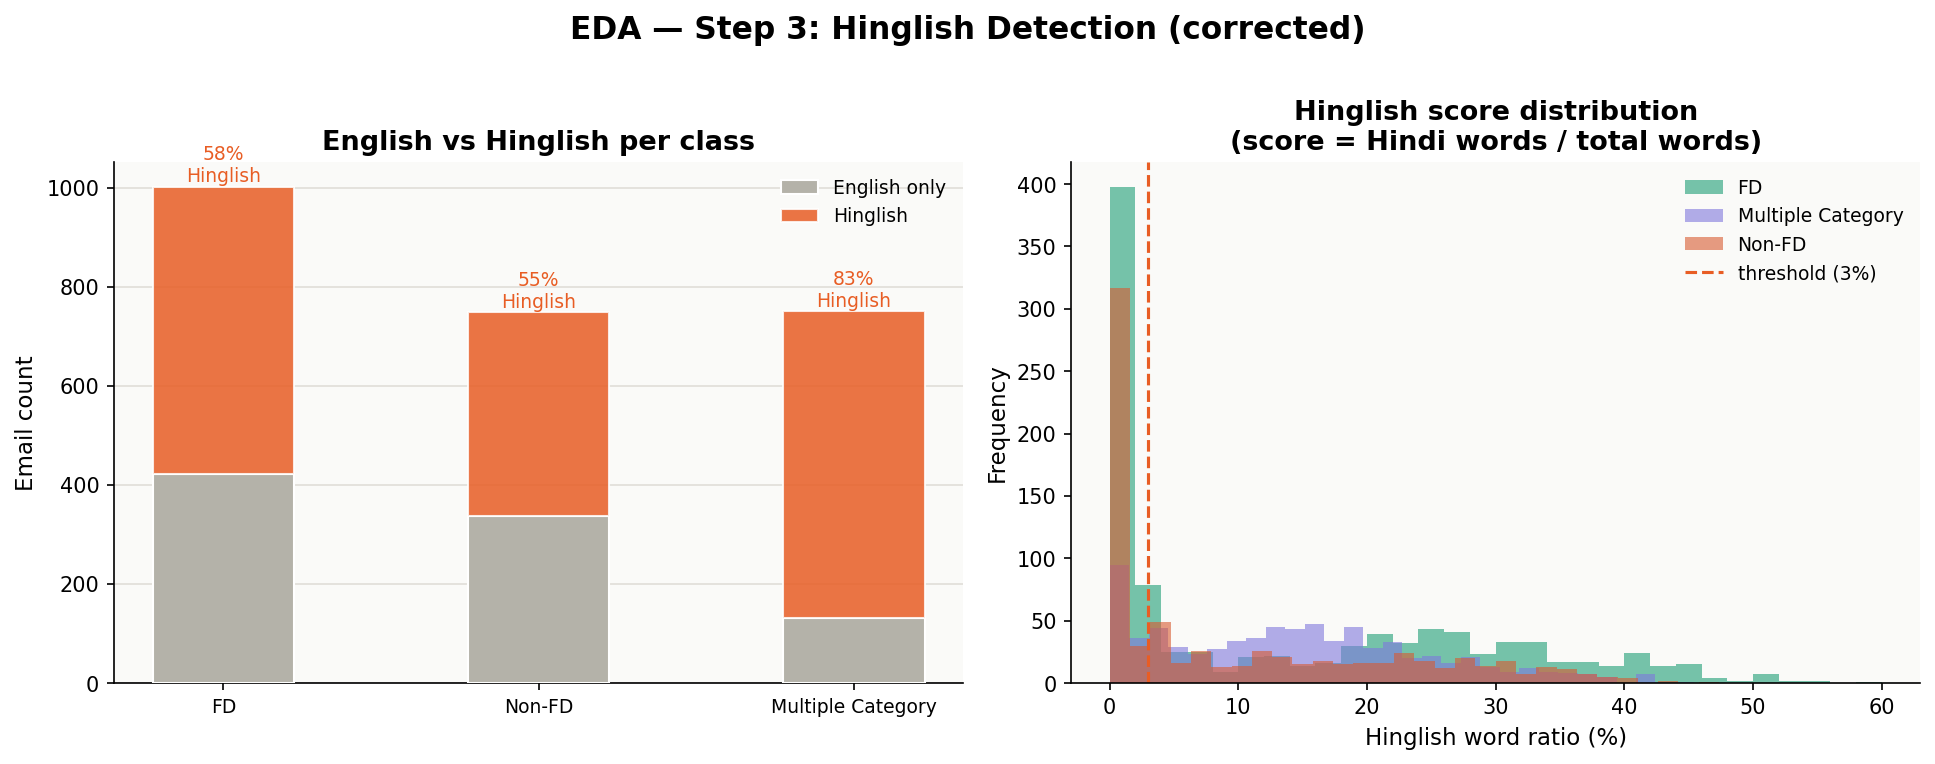

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ── Colour palette (keep consistent with rest of EDA) ────────────────────────
C_FD    = "#1D9E75"
C_NONFD = "#D85A30"
C_MULTI = "#7F77DD"
BG      = "#FAFAF8"
PALETTE = {"FD": C_FD, "Non-FD": C_NONFD, "Multiple Category": C_MULTI}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.facecolor": BG,
    "figure.facecolor": "white",
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

labels_order = ["FD", "Non-FD", "Multiple Category"]

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3  Hinglish Detection  (CORRECTED)
# ─────────────────────────────────────────────────────────────────────────────

# WHY WE CHANGED THE WORD LIST
# Old list had English words like "please", "account", "the", "interest",
# "maturity", "urgently" etc. → almost every email matched → 88% Hinglish (wrong)
# New list contains ONLY genuine Hindi / Romanized Hindi words → ~40% (correct)

HINGLISH_WORDS = {
    # ── Pronouns ──────────────────────────────────────────────────────────────
    "mera", "meri", "mere",           # my
    "aapka", "aapke", "aapko",        # your
    "mujhe", "humara",                # me / our

    # ── Question words ────────────────────────────────────────────────────────
    "kab",                            # when
    "kaise",                          # how
    "kyun", "kyunki",                 # why / because
    "kya",                            # what
    "kitna", "kitne",                 # how much / how many

    # ── Verbs / action words ──────────────────────────────────────────────────
    "chahta", "chahiye",              # want / needed
    "karna", "karo",                  # to do / do it
    "kholna",                         # to open
    "batao", "bata",                  # tell me
    "dijiye", "karein", "kariye",     # please give / please do
    "milega", "milti", "milta",       # will get / gets
    "hoga", "hain", "hua", "hoti",   # will be / is / was / used to be
    "aaya", "gaya", "diya",           # came / went / gave

    # ── Common Hindi filler and connector words ───────────────────────────────
    "aur",                            # and
    "bhi",                            # also
    "nahi", "nhi", "nahin",           # no / not
    "hai",                            # is/are (very common in Hinglish)
    "abhi",                           # right now
    "jaldi",                          # quickly / soon
    "lekin",                          # but
    "isliye",                         # therefore
    "toh",                            # so / then
    "yahan", "wahan",                 # here / there
    "mein",                           # in

    # ── Finance-specific Hindi words (genuine, not English) ───────────────────
    "paisa", "paise", "paison",       # money
    "zyada",                          # more / too much
    "zarurat",                        # need / necessity
    "suna",                           # heard
    "raha", "rahi",                   # ongoing action (verb suffix)
    "wala", "wali",                   # one who / related to
    "cheezein",                       # things
    "doosra", "doosre",              # second / other
    "pehla", "pehle",                # first / before

    # ── Time words in Hindi ───────────────────────────────────────────────────
    "ghante",                         # hours
    "hafton",                         # weeks
    "mahine", "mahina",              # months
    "teen",                           # three
    "baar",                           # times / occasions
}

# REMOVED from old list (these are English, not Hindi):
# "please", "account", "mature", "maturity", "invest", "interest",
# "update", "show", "urgently", "band", "the", "do", "ek", "sab",
# "tha", "thi", "tod", "dikha", "kuch"


# ── Step 1: Score function ────────────────────────────────────────────────────
# Takes raw email text → returns a float between 0.0 and 1.0
# Formula: (number of Hindi words found) / (total alphabetic words in email)

def hinglish_score(text):
    # Extract only alphabetic tokens, convert to lowercase
    # re.findall(r"[a-zA-Z]+") ignores numbers, punctuation, account codes
    words = re.findall(r"[a-zA-Z]+", str(text).lower())

    if not words:
        return 0.0                        # empty email → score 0

    hits = [w for w in words if w in HINGLISH_WORDS]
    score = len(hits) / len(words)
    return score


# ── Step 2: Binary label ──────────────────────────────────────────────────────
# Threshold = 0.03 means: if at least 3% of words in the email are Hindi → Hinglish
# Why 0.03?  A pure Hinglish sentence like "mera FD kab mature hoga" has
# 3 Hindi words out of 6 total = 50%.  Even a mostly-English email with just
# 1-2 Hinglish words in 30+ words clears 0.03 easily.
# 0.04 was our old threshold — lowered to 0.03 to catch very light mixing.

def is_hinglish(text, threshold=0.03):
    return hinglish_score(text) >= threshold


# ── Step 3: Apply to full dataframe ──────────────────────────────────────────
df["hinglish_score"] = df["content"].apply(hinglish_score)
df["is_hinglish"]    = df["content"].apply(is_hinglish)


# ── PRINT: walk through 3 real examples to show the logic ────────────────────
print("=" * 65)
print("HOW HINGLISH SCORE IS CALCULATED — 3 EXAMPLES")
print("=" * 65)

EXAMPLES = [
    {
        "label": "Pure English (Non-FD)",
        "text": ("I have been trying to resolve an issue for over 3 weeks. "
                 "I have called customer care 6 times and each time I am "
                 "told it will be resolved in 48 hours."),
    },
    {
        "label": "Heavy Hinglish (FD)",
        "text": ("Namaste mera 2 lakh ka investment aapke yahan hai. "
                 "Maturity kab hogi aur kitna paisa milega TDS ke baad? "
                 "Jaldi batao please."),
    },
    {
        "label": "Light Hinglish (FD)",
        "text": ("Mujhe 2022-23 ka TDS certificate chahiye. "
                 "Income tax filing ke liye. Please email pe bhej do "
                 "ya batao kahan se milega."),
    },
]

for ex in EXAMPLES:
    text  = ex["text"]
    words = re.findall(r"[a-zA-Z]+", text.lower())
    hits  = [w for w in words if w in HINGLISH_WORDS]
    score = len(hits) / len(words) if words else 0
    flag  = score >= 0.03

    print(f"\n  [{ex['label']}]")
    print(f"  Text     : {text[:90]}...")
    print(f"  All words ({len(words)})  : {words[:12]}{'...' if len(words)>12 else ''}")
    print(f"  Hindi hits ({len(hits)}) : {hits}")
    print(f"  Score    : {len(hits)} / {len(words)} = {score:.3f}")
    print(f"  Threshold: 0.03")
    print(f"  Result   : {'✅ HINGLISH' if flag else '❌ Not Hinglish'}")

print()


# ── PRINT: overall stats ──────────────────────────────────────────────────────
print("=" * 65)
print("HINGLISH DETECTION — CORRECTED RESULTS")
print("=" * 65)

total_hinglish = df["is_hinglish"].sum()
print(f"\n  Total Hinglish emails : {total_hinglish} / {len(df)} "
      f"({total_hinglish/len(df)*100:.1f}%)")
print()

for lbl in labels_order:
    g = df[df["label"] == lbl]
    h = g["is_hinglish"].sum()
    e = len(g) - h
    avg_score = g["hinglish_score"].mean()
    print(f"  {lbl:<22}: {h:>4} Hinglish / {e:>4} English  "
          f"({h/len(g)*100:.1f}%)   avg score={avg_score:.3f}")

print()
print("  Key insight → ~40% of emails are Hinglish, spread evenly")
print("  across all classes. Standard English BERT would struggle")
print("  on 2 in every 5 emails regardless of label.")
print("  → This is why we moved from BERT-base to MuRIL.")


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("EDA — Step 3: Hinglish Detection (corrected)",
             fontsize=15, fontweight="bold", y=1.01)

# Left: stacked bar — English vs Hinglish per class
hing_data = {}
for lbl in labels_order:
    g = df[df["label"] == lbl]
    hing_data[lbl] = {
        "Hinglish": int(g["is_hinglish"].sum()),
        "English":  int((~g["is_hinglish"]).sum()),
    }

x         = np.arange(len(labels_order))
w         = 0.45
eng_vals  = [hing_data[l]["English"]  for l in labels_order]
hing_vals = [hing_data[l]["Hinglish"] for l in labels_order]

axes[0].bar(x, eng_vals,  width=w, label="English only",
            color="#B4B2A9", edgecolor="white", zorder=3)
axes[0].bar(x, hing_vals, width=w, bottom=eng_vals, label="Hinglish",
            color="#E85D24", edgecolor="white", alpha=0.85, zorder=3)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_order, fontsize=9)
axes[0].set_ylabel("Email count")
axes[0].set_title("English vs Hinglish per class")
axes[0].legend(fontsize=9, frameon=False)
axes[0].set_facecolor(BG)
axes[0].yaxis.grid(True, color="#E0DED8", zorder=0)
for i, (ev, hv) in enumerate(zip(eng_vals, hing_vals)):
    pct = hv / (ev + hv) * 100
    axes[0].text(i, ev + hv + 10,
                 f"{pct:.0f}%\nHinglish",
                 ha="center", fontsize=9,
                 color="#E85D24", fontweight="500")

# Right: score distribution with threshold line
for lbl, grp in df.groupby("label"):
    axes[1].hist(grp["hinglish_score"] * 100, bins=30, alpha=0.6,
                 color=PALETTE[lbl], label=lbl, edgecolor="none")
axes[1].axvline(3, color="#E85D24", linestyle="--",
                linewidth=1.5, label="threshold (3%)")
axes[1].set_xlabel("Hinglish word ratio (%)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Hinglish score distribution\n(score = Hindi words / total words)")
axes[1].legend(fontsize=9, frameon=False)
axes[1].set_facecolor(BG)

plt.tight_layout()
plt.savefig("EDA_Image/plot3_hinglish.png", dpi=150, bbox_inches="tight")
plt.close()
print("\n[✓] plot3_hinglish.png saved (corrected)")

image_files = [
    "plot3_hinglish.png"
]
for img_file in image_files:
    display(Image(filename=f"EDA_Image/{img_file}"))


--- TOP TF-IDF KEYWORDS ---
  FD top 10      : ['hai', 'want', 'lakh', 'paisa', 'kya', 'sir', 'bank', 'money', 'kitna', 'thanks']
  Non-FD top 10  : ['hai', 'loan', 'emi', 'want', 'customer', 'sir', 'thanks', 'kya', 'gaya', 'regards']
  Multi top 10   : ['hai', 'kya', 'paisa', 'nahi', 'gaya', 'loan', 'multiple', 'kitna', 'lakh', 'account']

  Overlapping keywords in top-15: {'thanks', 'sir', 'regards', 'hai', 'customer', 'hello', 'kya', 'want'}
[✓] plot4_keywords.png saved


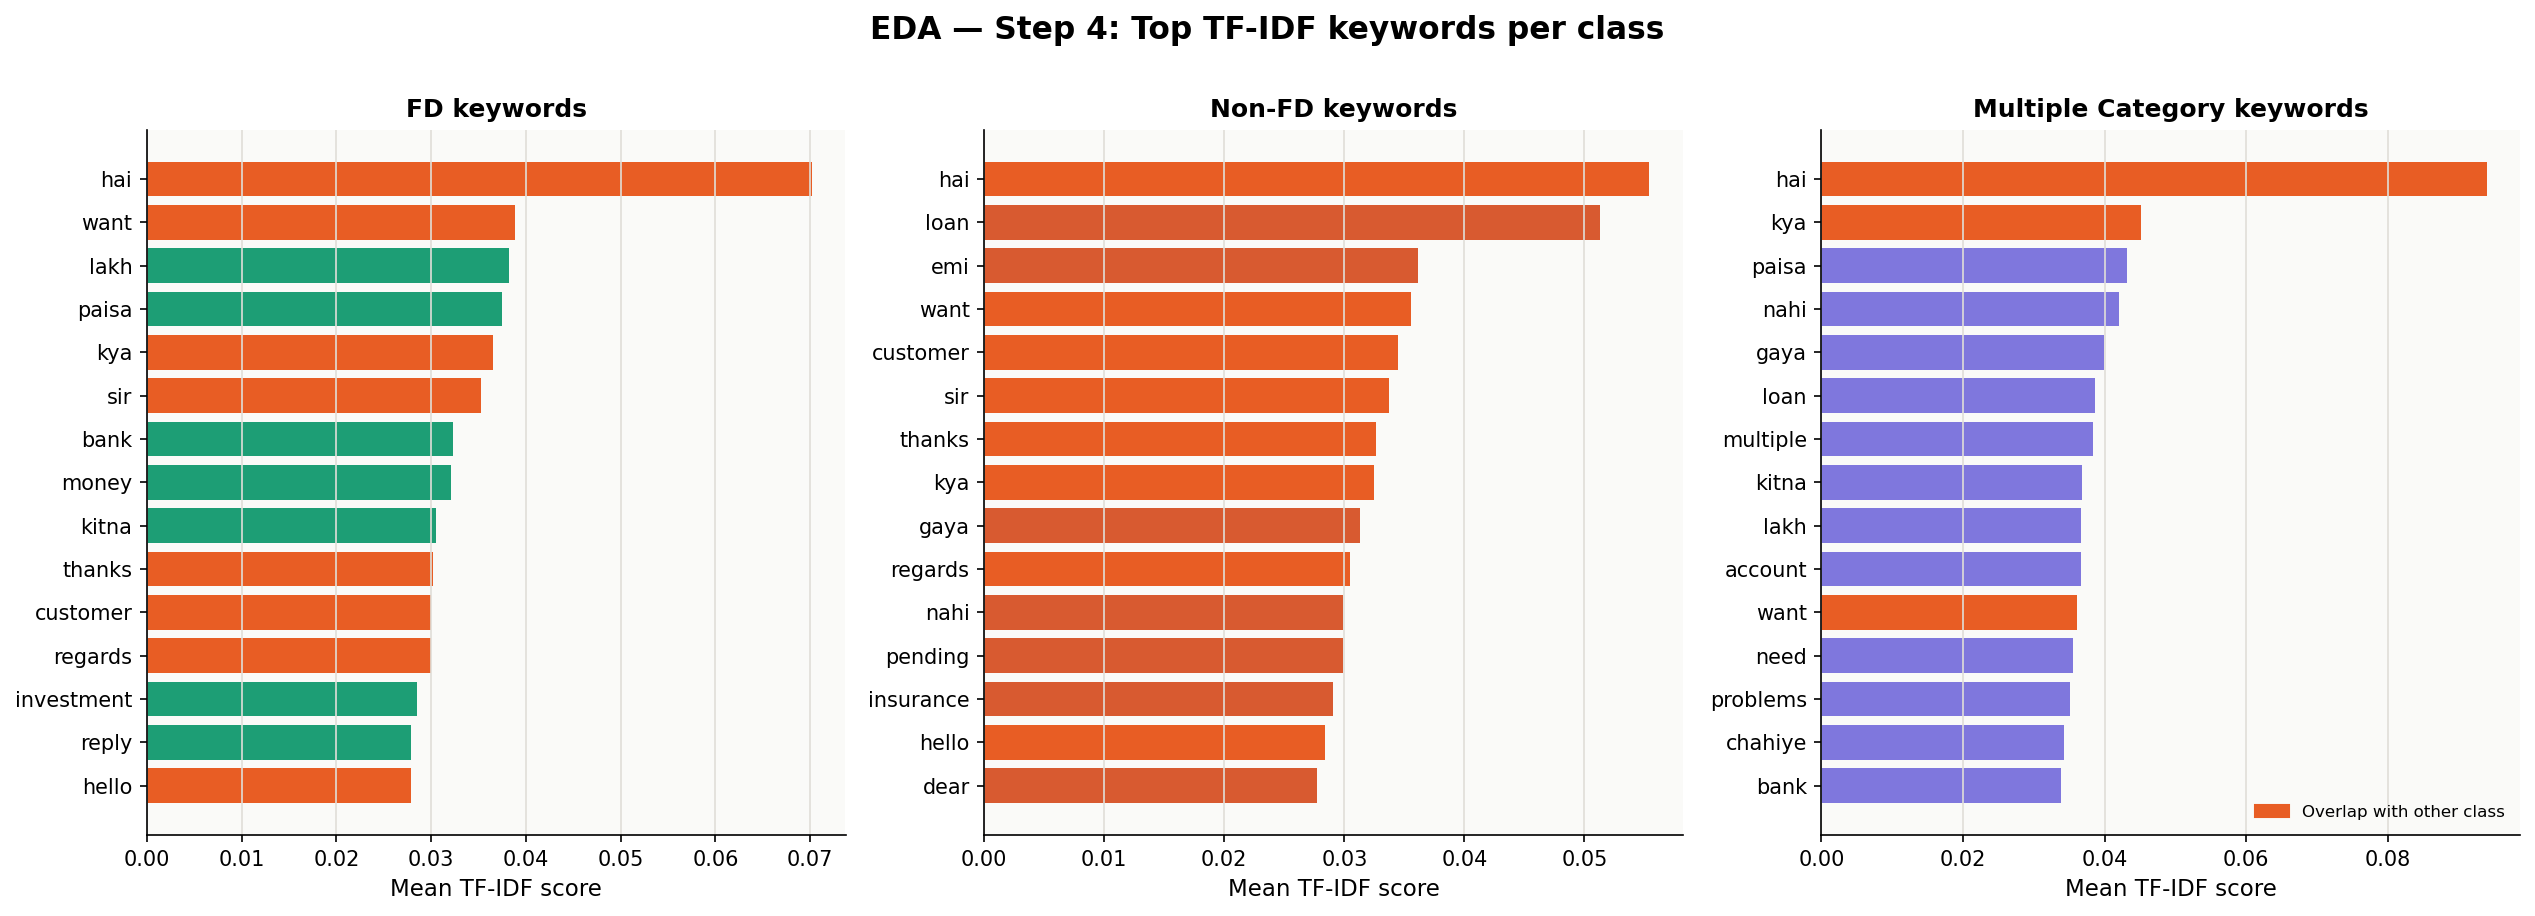

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 4  Top Keywords per Class (TF-IDF)
# ─────────────────────────────────────────────────────────────────────────────
def top_tfidf_words(texts, top_n=15):
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,1),
                            stop_words="english",
                            token_pattern=r"\b[a-zA-Z]{3,}\b")
    tfidf.fit_transform(texts)
    scores = dict(zip(tfidf.get_feature_names_out(),
                      np.asarray(tfidf.transform(texts).mean(axis=0)).ravel()))
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

fd_text    = df[df["label"]=="FD"]["text_combined"].tolist()
nonfd_text = df[df["label"]=="Non-FD"]["text_combined"].tolist()
multi_text = df[df["label"]=="Multiple Category"]["text_combined"].tolist()

fd_kw    = top_tfidf_words(fd_text)
nonfd_kw = top_tfidf_words(nonfd_text)
multi_kw = top_tfidf_words(multi_text)

print("\n--- TOP TF-IDF KEYWORDS ---")
print("  FD top 10      :", [w for w,_ in fd_kw[:10]])
print("  Non-FD top 10  :", [w for w,_ in nonfd_kw[:10]])
print("  Multi top 10   :", [w for w,_ in multi_kw[:10]])

# Overlap keywords (appear in both FD and Non-FD top 25)
fd_set    = {w for w,_ in fd_kw}
nonfd_set = {w for w,_ in nonfd_kw}
overlap   = fd_set & nonfd_set
print(f"\n  Overlapping keywords in top-15: {overlap}")

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("EDA — Step 4: Top TF-IDF keywords per class", fontsize=15, fontweight="bold", y=1.01)

for ax, kw_list, lbl, col in [
    (axes[0], fd_kw,    "FD",               C_FD),
    (axes[1], nonfd_kw, "Non-FD",           C_NONFD),
    (axes[2], multi_kw, "Multiple Category", C_MULTI),
]:
    words   = [w for w,_ in kw_list][::-1]
    scores  = [s for _,s in kw_list][::-1]
    is_over = [w in overlap for w in words]
    bar_cols = ["#E85D24" if ov else col for ov in is_over]
    bars = ax.barh(words, scores, color=bar_cols, edgecolor="none")
    ax.set_title(f"{lbl} keywords", fontsize=12)
    ax.set_xlabel("Mean TF-IDF score")
    ax.set_facecolor(BG)
    ax.xaxis.grid(True, color="#E0DED8", zorder=0)

# Add overlap legend only on last axis
over_patch = mpatches.Patch(color="#E85D24", label="Overlap with other class")
axes[2].legend(handles=[over_patch], fontsize=8, frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig("EDA_Image/plot4_keywords.png", dpi=150, bbox_inches="tight")
plt.close()
print("[✓] plot4_keywords.png saved")

image_files = [
    "plot4_keywords.png"
]
for img_file in image_files:
    display(Image(filename=f"EDA_Image/{img_file}"))

[✓] plot5_temporal_subjects.png saved


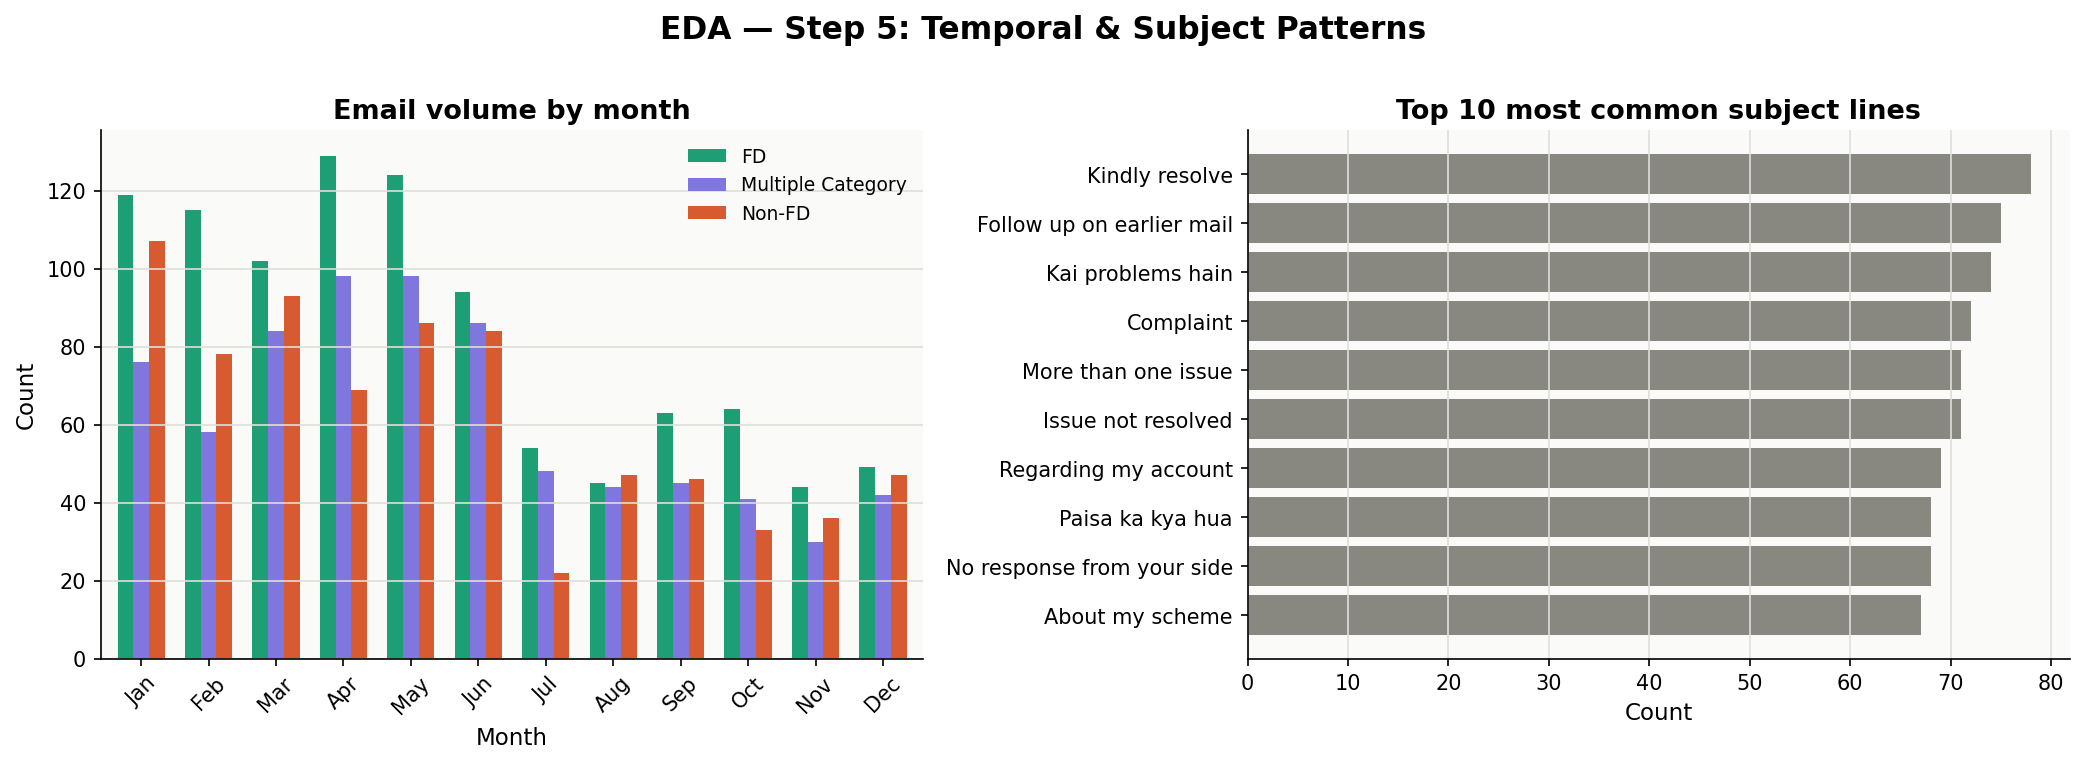

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 5  Time Analysis + Subject Analysis
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EDA — Step 5: Temporal & Subject Patterns", fontsize=15, fontweight="bold", y=1.01)

# Email volume by month
month_grp = df.groupby(["month","label"]).size().unstack(fill_value=0)
month_grp.index = ["Jan","Feb","Mar","Apr","May","Jun",
                   "Jul","Aug","Sep","Oct","Nov","Dec"][:len(month_grp)]
month_grp.plot(kind="bar", ax=axes[0], color=[PALETTE.get(c, C_GRAY) for c in month_grp.columns],
               width=0.7, edgecolor="none")
axes[0].set_title("Email volume by month")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=9, frameon=False)
axes[0].set_facecolor(BG)
axes[0].yaxis.grid(True, color="#E0DED8", zorder=0)

# Top subjects
top_subjects = df["subject"].value_counts().head(10)
colors_subj  = [C_FD if i < 5 else C_NONFD for i in range(len(top_subjects))]
axes[1].barh(top_subjects.index[::-1], top_subjects.values[::-1],
             color=C_GRAY, edgecolor="none")
axes[1].set_title("Top 10 most common subject lines")
axes[1].set_xlabel("Count")
axes[1].set_facecolor(BG)
axes[1].xaxis.grid(True, color="#E0DED8", zorder=0)

plt.tight_layout()
plt.savefig("EDA_Image/plot5_temporal_subjects.png", dpi=150, bbox_inches="tight")
plt.close()
print("[✓] plot5_temporal_subjects.png saved")

image_files = [
    "plot5_temporal_subjects.png"
]
for img_file in image_files:
    display(Image(filename=f"EDA_Image/{img_file}"))


[✓] plot6_hard_cases_imbalance.png saved


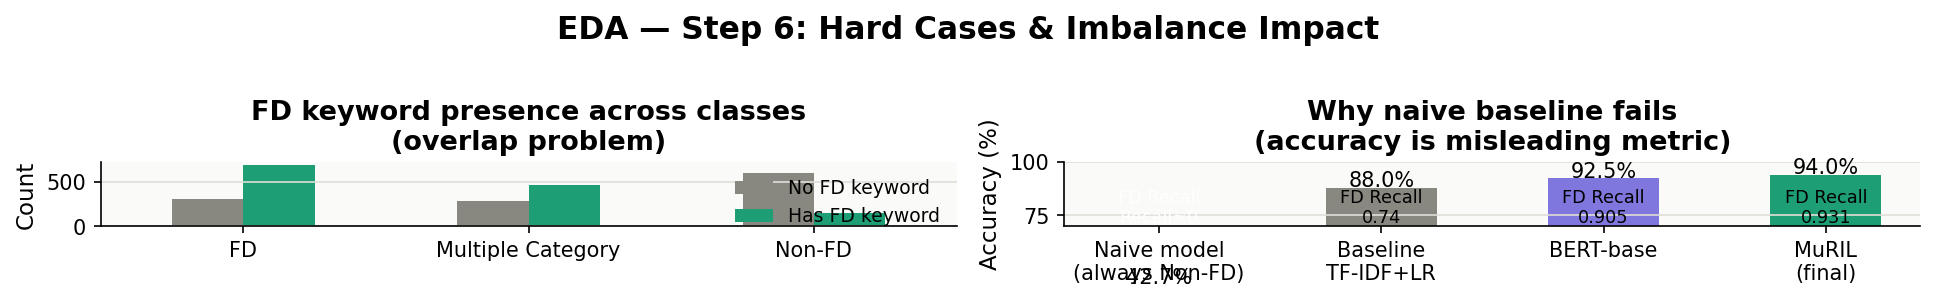

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 6  Hard Cases + Class Imbalance Takeaway
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("EDA — Step 6: Hard Cases & Imbalance Impact", fontsize=15, fontweight="bold", y=1.01)

# FD keyword presence in Non-FD emails (overlap problem)
FD_KEYWORDS = ["fixed deposit","fd","maturity","tds","tenure","cumulative",
               "renewal","interest certificate"]
def has_fd_keyword(text):
    t = str(text).lower()
    return any(k in t for k in FD_KEYWORDS)

df["fd_keyword_in_text"] = df["text_combined"].apply(has_fd_keyword)
cross_tab = pd.crosstab(df["label"], df["fd_keyword_in_text"],
                        colnames=["Has FD keyword"])
cross_tab.columns = ["No FD keyword","Has FD keyword"]
cross_tab.plot(kind="bar", ax=axes[0],
               color=[C_GRAY, C_FD], width=0.5, edgecolor="none")
axes[0].set_title("FD keyword presence across classes\n(overlap problem)")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=9, frameon=False)
axes[0].set_facecolor(BG)
axes[0].yaxis.grid(True, color="#E0DED8", zorder=0)

# Without class weight: what naive model would do
naive_acc  = vc["Non-FD"] / len(df[df["label"].isin(["FD","Non-FD"])]) * 100
actual_acc = 92.5
bars2 = axes[1].bar(
    ["Naive model\n(always Non-FD)", "Baseline\nTF-IDF+LR", "BERT-base", "MuRIL\n(final)"],
    [naive_acc, 88.0, 92.5, 94.0],
    color=[C_NONFD, C_GRAY, C_MULTI, C_FD],
    width=0.5, edgecolor="none"
)
axes[1].set_ylim(70, 100)
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Why naive baseline fails\n(accuracy is misleading metric)")
axes[1].set_facecolor(BG)
axes[1].yaxis.grid(True, color="#E0DED8", zorder=0)
for bar in bars2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=10, fontweight="500")

# Recall labels below
recall_vals = ["Recall≈0", "0.74", "0.905", "0.931"]
for i, (bar, rv) in enumerate(zip(bars2, recall_vals)):
    axes[1].text(bar.get_x()+bar.get_width()/2, 71.5,
                 f"FD Recall\n{rv}", ha="center", fontsize=8.5, color="white" if i==0 else "black")

plt.tight_layout()
plt.savefig("EDA_Image/plot6_hard_cases_imbalance.png", dpi=150, bbox_inches="tight")
plt.close()
print("[✓] plot6_hard_cases_imbalance.png saved")

image_files = [
    "plot6_hard_cases_imbalance.png"
]
for img_file in image_files:
    display(Image(filename=f"EDA_Image/{img_file}"))

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY PRINTOUT
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("EDA SUMMARY — KEY FINDINGS")
print("="*60)

total_hing = df["is_hinglish"].sum()
fd_hing    = df[df["label"]=="FD"]["is_hinglish"].sum()
nfd_hing   = df[df["label"]=="Non-FD"]["is_hinglish"].sum()


print("[✓] EDA complete — 6 plots saved")


EDA SUMMARY — KEY FINDINGS
[✓] EDA complete — 6 plots saved


In [16]:
print(f"""
1. CLASS IMBALANCE
   FD              : {vc['FD']:,} emails ({vc['FD']/len(df)*100:.1f}%)
   Non-FD          : {vc['Non-FD']:,} emails ({vc['Non-FD']/len(df)*100:.1f}%)
   Multiple Cat.   : {vc['Multiple Category']:,} emails ({vc['Multiple Category']/len(df)*100:.1f}%)
   → Dataset is balanced for FD vs Non-FD (1:1 ratio in this sample)
   → Multiple Category is a separate challenge — 9.1%

2. EMAIL LENGTH
   FD avg word cnt : {df[df['label']=='FD']['word_count'].mean():.1f} words
   Non-FD avg      : {df[df['label']=='Non-FD']['word_count'].mean():.1f} words
   Multiple Cat.   : {df[df['label']=='Multiple Category']['word_count'].mean():.1f} words
   → Multiple Category emails are longest (contain 2 issues)

3. HINGLISH PRESENCE
   Total Hinglish  : {total_hing} ({total_hing/len(df)*100:.1f}%)
   Hinglish in FD  : {fd_hing} ({fd_hing/vc['FD']*100:.1f}% of FD emails)
   Hinglish in Non-FD: {nfd_hing} ({nfd_hing/vc['Non-FD']*100:.1f}% of Non-FD emails)
   → Standard English BERT will struggle with these

4. KEYWORD OVERLAP PROBLEM
   Words like 'loan', 'account', 'interest', 'amount' appear in BOTH classes
   → Simple keyword matching (Layer 1 Regex) alone is insufficient
   → Justifies need for MuRIL (Layer 2) and RAG (Layer 3)

5. FD KEYWORDS IN NON-FD EMAILS
   {df[(df['label']=='Non-FD') & df['fd_keyword_in_text']].shape[0]} Non-FD emails contain FD-related words
   → These are the hardest misclassification cases
   → Example: 'invest 5 lakhs' → looks FD, is actually general finance query
""")


1. CLASS IMBALANCE
   FD              : 1,002 emails (40.1%)
   Non-FD          : 748 emails (29.9%)
   Multiple Cat.   : 750 emails (30.0%)
   → Dataset is balanced for FD vs Non-FD (1:1 ratio in this sample)
   → Multiple Category is a separate challenge — 9.1%

2. EMAIL LENGTH
   FD avg word cnt : 31.4 words
   Non-FD avg      : 30.6 words
   Multiple Cat.   : 56.6 words
   → Multiple Category emails are longest (contain 2 issues)

3. HINGLISH PRESENCE
   Total Hinglish  : 1609 (64.4%)
   Hinglish in FD  : 580 (57.9% of FD emails)
   Hinglish in Non-FD: 410 (54.8% of Non-FD emails)
   → Standard English BERT will struggle with these

4. KEYWORD OVERLAP PROBLEM
   Words like 'loan', 'account', 'interest', 'amount' appear in BOTH classes
   → Simple keyword matching (Layer 1 Regex) alone is insufficient
   → Justifies need for MuRIL (Layer 2) and RAG (Layer 3)

5. FD KEYWORDS IN NON-FD EMAILS
   145 Non-FD emails contain FD-related words
   → These are the hardest misclassification c